# Wordle: Gemma 3 1B + REINFORCE (policy gradient)

This notebook trains the same **`WordleGPT2Policy`** (frozen causal LM + linear head) as `week12_implementation.ipynb`, but with **REINFORCE** (Monte Carlo policy gradients) instead of Evolution Strategies. It **defaults to `google/gemma-3-1b-it`** (`RUN_PROFILE="gemma_full"`); use `RUN_PROFILE="smoke"` for DistilGPT-2 only when debugging.

**Implementation:** `src/wordle_reinforce_lm.py` (`train_reinforce_wordle`).

**Requires:** `torch`, `transformers>=4.50.0`, `numpy`, `matplotlib`. Optional **`pip install peft`** if `USE_LORA=True`. Gated Gemma access on Hugging Face as in Week 12.

## 1. Imports and device helpers

Re-run this cell after changing `src/wordle_reinforce_lm.py` (`importlib.reload` picks up new kwargs such as `show_progress`). If errors persist, **Restart kernel** and run all.

In [5]:
import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

_here = Path.cwd().resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from wordle_env import load_wordle_environment
from wordle_gpt2_policy import WordleGPT2Policy, TRANSFORMERS_AVAILABLE
from wordle_gpt2_warmstart import supervised_warm_start_wordle
import wordle_reinforce_lm
importlib.reload(wordle_reinforce_lm)
from wordle_reinforce_lm import train_reinforce_wordle, evaluate_wordle_lm_policy

if not TRANSFORMERS_AVAILABLE:
    raise ImportError("Install transformers: pip install transformers")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps_backend = getattr(torch.backends, "mps", None)
    if mps_backend is not None and mps_backend.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def default_model_load_kwargs(device: torch.device) -> tuple[dict, str]:
    if device.type != "cuda":
        return {}, "float32"
    if torch.cuda.is_bf16_supported():
        return {"torch_dtype": torch.bfloat16}, "bfloat16"
    return {"torch_dtype": torch.float16}, "float16"


print("ROOT:", ROOT)
print("wordle_reinforce_lm:", wordle_reinforce_lm.__file__)
print("torch:", torch.__version__, "| device will be chosen in §2")

ROOT: /content
wordle_reinforce_lm: /content/wordle_reinforce_lm.py
torch: 2.10.0+cu128 | device will be chosen in §2


## 2. Hyperparameters

**Default:** `RUN_PROFILE="gemma_full"` (`google/gemma-3-1b-it`, chat template), same backbone intent as `week12_implementation.ipynb`.

- **`RUN_PROFILE="smoke"`**: DistilGPT-2, short runs for debugging.
- **`RUN_PROFILE="gemma_full"`**: `google/gemma-3-1b-it` with chat template.

**Vocab / targets:** With **`MOCK_ENV=False`**, §3 passes **`target_pool=list(policy.words)`** so the secret is always one of the policy’s actions. To study scaling, set a finite **`"max_vocab"`** in `PROFILE_CONFIGS` (e.g. `32`, `128`); use **`None`** for the full truncated lexicon (large). With **`MOCK_ENV=True`**, secrets come from `MOCK_WORDLE_TARGETS`; keep `max_vocab` large enough that those words stay in `policy.words` (defaults use 8).

`warm_start_steps` is set per profile (like Week 12 ES). REINFORCE knobs: learning rate, episodes per iteration, `gamma`, `entropy_coef`, `n_iterations`.

**If warm-start CE drifts up or stays \(\gg \ln K\):** use a **smaller `max_vocab`** first (easier \(K\)-way CE), **`WARM_START_LR` ~`1e-4`** (head-only on frozen LM), then scale vocab. **`ENTROPY_COEF`** and **`N_EPISODES_PER_ITER`** help REINFORCE after warm-start.

In [6]:
SEED = 42
RUN_PROFILE = "gemma_full"  # "smoke" (DistilGPT-2) or "gemma_full" (google/gemma-3-1b-it)
DEVICE = choose_device()

MOCK_ENV = False
USE_PRIME_TARGETS = False
USE_LORA = False
LORA_R = 4
RICHER_PROMPT = True

# REINFORCE (slightly gentler LR, more rollouts/iter, a bit more entropy for exploration)
REINFORCE_LR = 2e-4
GAMMA = 0.99
ENTROPY_COEF = 0.02
N_EPISODES_PER_ITER = 16
MAX_TURNS = 6
NORMALIZE_ADVANTAGES = True

# Head-only CE on frozen LM: 3e-4 often wanders; try 1e-4 (or 5e-5 if loss still noisy).
WARM_START_LR = 1e-4

PROFILE_CONFIGS = {
    "smoke": {
        "model_name": "distilgpt2",
        "use_chat_template": False,
        "chat_generation_prompt": False,
        "max_prompt_length": 256,
        "max_vocab": 8,
        "n_iterations": 30,
        "eval_every": 5,
        "eval_n_episodes": 8,
        "num_train_examples": 128,
        "num_eval_examples": 16,
        "warm_start_steps": 12,
    },
    "gemma_full": {
        "model_name": "google/gemma-3-1b-it",
        "use_chat_template": True,
        "chat_generation_prompt": True,
        "max_prompt_length": 512,
        # Start finite for warm-start + REINFORCE; set None for full truncated lexicon (~634+ words).
        "max_vocab": 32,
        "n_iterations": 40,
        "eval_every": 10,
        "eval_n_episodes": 24,
        "num_train_examples": 2000,
        "num_eval_examples": 20,
        "warm_start_steps": 0,
    },
}

if RUN_PROFILE not in PROFILE_CONFIGS:
    raise ValueError(f"RUN_PROFILE must be one of {sorted(PROFILE_CONFIGS)}, got {RUN_PROFILE!r}")

cfg = PROFILE_CONFIGS[RUN_PROFILE]
MODEL_NAME = cfg["model_name"]
USE_CHAT_TEMPLATE = cfg["use_chat_template"]
CHAT_GENERATION_PROMPT = cfg["chat_generation_prompt"]
MAX_PROMPT_LENGTH = cfg["max_prompt_length"]
N_ITERATIONS = cfg["n_iterations"]
EVAL_EVERY = cfg["eval_every"]
EVAL_N_EPISODES = cfg["eval_n_episodes"]
NUM_TRAIN_EXAMPLES = cfg["num_train_examples"]
NUM_EVAL_EXAMPLES = cfg["num_eval_examples"]
WARM_START_STEPS = cfg["warm_start_steps"]

if MOCK_ENV:
    from wordle_env import MOCK_WORDLE_TARGETS as _MOCK_T
    _MOCK_ACTIONS = len(_MOCK_T)
else:
    _MOCK_ACTIONS = None

MAX_VOCAB = _MOCK_ACTIONS if MOCK_ENV else cfg["max_vocab"]
MODEL_LOAD_KWARGS, MODEL_DTYPE_NAME = default_model_load_kwargs(DEVICE)

np.random.seed(SEED)
torch.manual_seed(SEED)

device = DEVICE
print(
    f"Profile: {RUN_PROFILE} | Model: {MODEL_NAME} | REINFORCE | LoRA: {USE_LORA}\n"
    f"  device={device}  dtype={MODEL_DTYPE_NAME}  MAX_PROMPT_LENGTH={MAX_PROMPT_LENGTH}  MAX_VOCAB={MAX_VOCAB}\n"
    f"  n_iterations={N_ITERATIONS}  episodes/iter={N_EPISODES_PER_ITER}  eval_every={EVAL_EVERY}  warm_start_steps={WARM_START_STEPS}"
)
if MODEL_LOAD_KWARGS:
    print("model_load_kwargs:", MODEL_LOAD_KWARGS)

Profile: gemma_full | Model: google/gemma-3-1b-it | REINFORCE | LoRA: False
  device=cuda  dtype=bfloat16  MAX_PROMPT_LENGTH=512  MAX_VOCAB=32
  n_iterations=40  episodes/iter=16  eval_every=10  warm_start_steps=0
model_load_kwargs: {'torch_dtype': torch.bfloat16}


In [ ]:
import os
os.environ["HF_TOKEN"] = ""
print("Hugging Face token set as environment variable.")

Hugging Face token set as environment variable.


## 3. Environment and policy

- **`MOCK_ENV=True`:** small mock target list; Prime Intellect off (same as Week 12).
- **`MOCK_ENV=False`:** build the policy first, then **`load_wordle_environment(..., target_pool=list(policy.words))`**. Secrets are drawn only from the **same ordered list** as the policy actions (truncated by `max_vocab` in §2), so every episode is solvable in principle—use this to study REINFORCE vs **increasing `max_vocab`** (set a finite integer in your profile, or `None` for the full policy word list).

In [8]:
policy = WordleGPT2Policy(
    model_name=MODEL_NAME,
    use_prime_targets=USE_PRIME_TARGETS,
    max_vocab_size=MAX_VOCAB,
    max_prompt_length=MAX_PROMPT_LENGTH,
    include_mock_targets_in_vocab=True,
    richer_prompt=RICHER_PROMPT,
    use_chat_template=USE_CHAT_TEMPLATE,
    chat_generation_prompt=CHAT_GENERATION_PROMPT,
    use_lora=USE_LORA,
    lora_r=LORA_R,
    model_kwargs=MODEL_LOAD_KWARGS,
).to(device)

if MOCK_ENV:
    train_env = load_wordle_environment(
        num_train_examples=NUM_TRAIN_EXAMPLES,
        num_eval_examples=NUM_EVAL_EXAMPLES,
        use_prime_intellect=False,
    )
else:
    # Align secret-word distribution with the policy action set (same as using explicit target_pool in wordle_env).
    train_env = load_wordle_environment(
        num_train_examples=NUM_TRAIN_EXAMPLES,
        num_eval_examples=NUM_EVAL_EXAMPLES,
        use_prime_intellect=False,
        target_pool=list(policy.words),
    )

print(f"Action dim (|policy.words|): {policy.action_dim}")
if not MOCK_ENV:
    assert train_env.prime_env is not None
    n_targets = len(train_env.prime_env.dataset.targets)
    print(f"Env target_pool size (matches policy.words): {n_targets}")
    assert n_targets == len(policy.words)

trainable = policy.count_trainable_parameters()
total = policy.count_parameters()
print(f"Trainable params: {trainable:,} / {total:,}")

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

[OK] Local Wordle environment ready (32 target words from explicit target_pool).
Action dim (|policy.words|): 32
Env target_pool size (matches policy.words): 32
Trainable params: 36,896 / 999,922,848


## 4. Optional supervised warm-start

Cross-entropy toward the hidden target (label only), same module as the ES notebook. `warm_start_steps` comes from `PROFILE_CONFIGS` in §2 (400 for `gemma_full`, 12 for `smoke`). To skip, set `"warm_start_steps": 0` for your profile in `PROFILE_CONFIGS`.

In [9]:
# Warm-start parameters intentionally mirror the ES LoRA notebook
# (week12_implementation_LoRARun.ipynb) so the REINFORCE-vs-ES head-to-head
# starts both methods from the same supervised baseline:
#   - feedback_consistent_random=True: after turn 1, random pre-play guesses
#     are drawn only from words still consistent with accumulated feedback.
#     This produces crisp (state, secret) CE examples instead of noisy ones
#     where each new random guess ignores prior clues.
#   - batch_size=8: accumulate 8 examples per optimizer step. ~8x faster
#     wall-clock on Gemma and a lower-variance gradient. `n_steps` still
#     counts sampled episodes (so WARM_START_STEPS=400 means ~50 batched
#     updates across 400 episodes).
# If either of these diverges from the ES notebook's values, the subsequent
# REINFORCE-vs-ES comparison is confounded by the warm-start delta.
WARM_START_FEEDBACK_CONSISTENT = True
WARM_START_BATCH_SIZE = 8

if WARM_START_STEPS > 0:
    ws = supervised_warm_start_wordle(
        policy,
        train_env,
        n_steps=WARM_START_STEPS,
        lr=WARM_START_LR,
        max_turns=MAX_TURNS,
        device=device,
        seed=SEED,
        verbose=True,
        feedback_consistent_random=WARM_START_FEEDBACK_CONSISTENT,
        batch_size=WARM_START_BATCH_SIZE,
    )
    print("warm-start last loss:", ws["loss"][-1] if ws["loss"] else None)
    print(
        "  (feedback_consistent_random="
        f"{WARM_START_FEEDBACK_CONSISTENT}, batch_size={WARM_START_BATCH_SIZE}; "
        "matched to week12_implementation_LoRARun.ipynb for a fair "
        "REINFORCE-vs-ES head-to-head)"
    )

    # Post-warm-start greedy eval -- an explicit baseline so the eventual
    # REINFORCE curve can be read as "RL contribution on top of warm-start"
    # rather than "RL + warm-start combined". The ES notebook reports the
    # same number per stage; REINFORCE should report it too for comparability.
    _ws_eval_r, _ws_eval_success, _ws_eval_turns = evaluate_wordle_lm_policy(
        policy,
        train_env,
        n_episodes=EVAL_N_EPISODES,
        max_turns=MAX_TURNS,
        deterministic=True,
    )
    print(
        f"post-warm-start greedy eval ({EVAL_N_EPISODES} eps): "
        f"success={_ws_eval_success:.1%} "
        f"avg_return={_ws_eval_r:.3f} "
        f"avg_turns={_ws_eval_turns:.2f}"
    )
else:
    print("Skipping warm-start (WARM_START_STEPS=0).")

Skipping warm-start (WARM_START_STEPS=0).


## 5. REINFORCE training

Adam on trainable parameters (head ± LoRA). `train_reinforce_wordle(..., show_progress=True)` shows a **`tqdm`** bar over iterations (loss, mean train return, last greedy eval success). `pip install tqdm` if missing.

Checkpoint is saved in **§7** after training (and after §6 eval/plots if you run the full notebook). **`models/wordle_gemma_reinforce_head.<RUN_PROFILE>.pt`** (or `..._LoRA...` if LoRA): head, optional LoRA weights, `words`, `history`, REINFORCE hyperparameters, and optional **`final_eval`** if §6 ran first.

In [10]:
trainable_params = [p for p in policy.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable_params, lr=REINFORCE_LR)

history = train_reinforce_wordle(
    policy,
    train_env,
    optimizer,
    n_iterations=N_ITERATIONS,
    n_episodes_per_iter=N_EPISODES_PER_ITER,
    gamma=GAMMA,
    entropy_coef=ENTROPY_COEF,
    max_turns=MAX_TURNS,
    eval_every=EVAL_EVERY,
    eval_n_episodes=EVAL_N_EPISODES,
    normalize_advantages=NORMALIZE_ADVANTAGES,
    seed=SEED,
    show_progress=True,
)

print("Training loss (last):", history["loss"][-1] if history["loss"] else None)
print("Mean train return (last):", history["mean_return"][-1] if history["mean_return"] else None)

REINFORCE:   0%|          | 0/40 [00:00<?, ?iter/s]

Training loss (last): 0.04667973145842552
Mean train return (last): 1.3460416666666668


## 6. Final greedy eval and plots

- **§6a** — Greedy evaluation (needs `policy` from §5). Skip if you only want figures from a saved run.
- **§6b** — Figures. **Re-run this cell alone** to refresh the layout after edits. Keep `RELOAD_HISTORY_FROM = None` to use the in-memory `history` from §5 (kernel still has it). To plot **without** loading the model or re-running §2–§5, run **§1** (imports + `ROOT`), set `RELOAD_HISTORY_FROM` to your `.pt` path, then run **§6b** only.

In [11]:
mean_r, success, mean_turns = evaluate_wordle_lm_policy(
    policy,
    train_env,
    n_episodes=EVAL_N_EPISODES,
    max_turns=MAX_TURNS,
    deterministic=True,
)
print(f"Greedy eval — mean return: {mean_r:.3f}  success: {success:.1%}  mean turns: {mean_turns:.2f}")

Greedy eval — mean return: 1.630  success: 41.7%  mean turns: 5.00


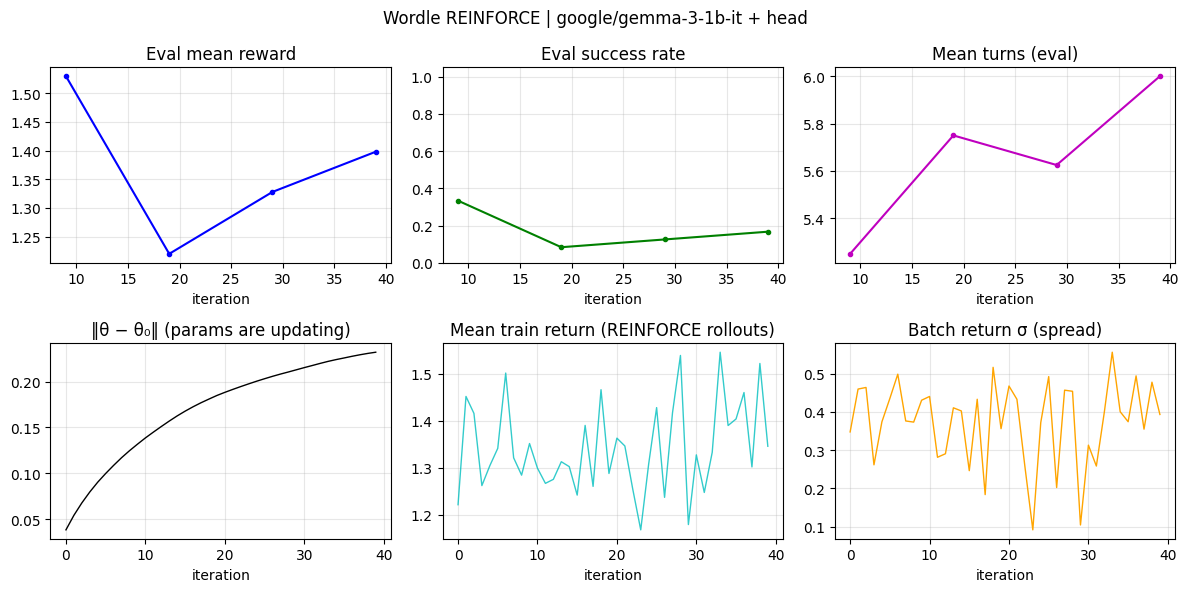

In [12]:
# §6b — Plots only (re-run this cell to refresh figures; no need to re-train)
# Set path to load `history` from a checkpoint, or None to use in-memory `history` from §5.
RELOAD_HISTORY_FROM = None  # e.g. ROOT / "models" / f"wordle_gemma_reinforce_head.{RUN_PROFILE}.pt"

_ckpt = None
if RELOAD_HISTORY_FROM is not None:
    try:
        _ckpt = torch.load(RELOAD_HISTORY_FROM, map_location="cpu", weights_only=False)
    except TypeError:
        _ckpt = torch.load(RELOAD_HISTORY_FROM, map_location="cpu")
    history = _ckpt["history"]

_rc = (_ckpt or {}).get("reinforce_config") or {}
_plot_eval_every = _rc.get("eval_every", globals().get("EVAL_EVERY", 10))
_plot_n_iter = _rc.get("n_iterations")
if _plot_n_iter is None:
    _plot_n_iter = globals().get("N_ITERATIONS")
if _plot_n_iter is None:
    _plot_n_iter = max(
        len(history.get("mean_return") or []),
        len(history.get("train_iter") or []),
        1,
    )

_model_name = (_ckpt or {}).get("model_name") or globals().get("MODEL_NAME", "")
_use_lora = (_ckpt or {}).get("use_lora")
if _use_lora is None:
    _use_lora = globals().get("USE_LORA", False)
_lora_r = globals().get("LORA_R", 4)

# Same 2×3 layout as week12_implementation_LoRARun.ipynb §6 (eval row + per-iter diagnostics)
it = history.get("iteration") or []
if not it and history.get("eval_success"):
    it = list(range(_plot_eval_every - 1, _plot_n_iter, _plot_eval_every))[
        : len(history["eval_success"])
    ]

ti = history.get("train_iter")
if not ti and history.get("mean_return"):
    ti = list(range(len(history["mean_return"])))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

if it and history.get("eval_return"):
    axes[0, 0].plot(it, history["eval_return"], "b-o", ms=3)
axes[0, 0].set_title("Eval mean reward")
axes[0, 0].set_xlabel("iteration")
axes[0, 0].grid(True, alpha=0.3)

if it and history.get("eval_success"):
    axes[0, 1].plot(it, history["eval_success"], "g-o", ms=3)
axes[0, 1].set_title("Eval success rate")
axes[0, 1].set_xlabel("iteration")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(True, alpha=0.3)

if it and history.get("eval_turns"):
    axes[0, 2].plot(it, history["eval_turns"], "m-o", ms=3)
axes[0, 2].set_title("Mean turns (eval)")
axes[0, 2].set_xlabel("iteration")
axes[0, 2].grid(True, alpha=0.3)

if ti and history.get("param_drift"):
    axes[1, 0].plot(ti, history["param_drift"], "k-", lw=1)
axes[1, 0].set_title("‖θ − θ₀‖ (params are updating)")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].grid(True, alpha=0.3)

if ti and history.get("mean_return"):
    axes[1, 1].plot(ti, history["mean_return"], "c-", lw=1, alpha=0.8)
axes[1, 1].set_title("Mean train return (REINFORCE rollouts)")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].grid(True, alpha=0.3)

if ti and history.get("batch_return_std"):
    axes[1, 2].plot(ti, history["batch_return_std"], "orange", lw=1)
axes[1, 2].set_title("Batch return σ (spread)")
axes[1, 2].set_xlabel("iteration")
axes[1, 2].grid(True, alpha=0.3)

rank_note = f" | LoRA r={_lora_r}" if _use_lora else ""
plt.suptitle(f"Wordle REINFORCE | {_model_name} + head{rank_note}")
plt.tight_layout()
plt.show()

## 7. Save checkpoint

Same layout as `week12_implementation.ipynb` §7: under `models/` at the repo root. Filename includes `RUN_PROFILE`. If you ran **§6** in this kernel, **`final_eval`** records the last greedy eval; if not, the checkpoint still has training `history`.

In [13]:
if USE_LORA:
    save_path = ROOT / "models" / f"wordle_gemma_reinforce_head_LoRA.{RUN_PROFILE}.pt"
else:
    save_path = ROOT / "models" / f"wordle_gemma_reinforce_head.{RUN_PROFILE}.pt"
save_path.parent.mkdir(parents=True, exist_ok=True)
payload = {
    "head": policy.head.state_dict(),
    "model_name": MODEL_NAME,
    "words": policy.words,
    "history": history,
    "use_lora": USE_LORA,
    "run_profile": RUN_PROFILE,
    "algorithm": "REINFORCE",
    "reinforce_config": {
        "reinforce_lr": REINFORCE_LR,
        "gamma": GAMMA,
        "entropy_coef": ENTROPY_COEF,
        "n_episodes_per_iter": N_EPISODES_PER_ITER,
        "n_iterations": N_ITERATIONS,
        "eval_every": EVAL_EVERY,
        "normalize_advantages": NORMALIZE_ADVANTAGES,
        "seed": SEED,
    },
    "model_load_kwargs": {k: str(v) for k, v in MODEL_LOAD_KWARGS.items()},
}
if getattr(policy, "_lm_trainable", False):
    payload["lm"] = policy.lm.state_dict()
try:
    payload["final_eval"] = {
        "mean_return": float(mean_r),
        "success": float(success),
        "mean_turns": float(mean_turns),
    }
except NameError:
    pass
torch.save(payload, save_path)
print("Saved:", save_path)

Saved: /content/models/wordle_gemma_reinforce_head.gemma_full.pt
